In [ ]:
import pandas as pd
df=pd.read_csv('/content/genetic_disease_dataset.csv')
df

,Age,Gender,Family_History,Hemoglobin,Fetal_Hemoglobin,RDW_CV,Serum_Ferritin,BRCA1_Expression,p53_Mutation,Sweat_Chloride,Sickled_RBC_Percent,IL6_Level,Disease
0,48,1,1,7.44,13.14,13.67,53.63,0.36,0,45.37,0.62,6.09,0
1,53,0,0,7.35,15.44,18.25,32.74,0.35,0,38.42,1.05,2.15,3
2,48,1,1,8.25,7.16,17.89,30.08,0.20,0,32.60,1.66,2.56,0
3,27,1,0,8.55,15.34,18.94,27.35,0.28,0,58.59,1.21,8.28,0
4,38,0,0,8.79,15.96,19.83,47.48,0.29,0,44.74,1.56,5.35,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,52,1,0,13.30,0.83,14.06,112.84,0.10,0,69.57,2.82,22.22,2
996,57,0,1,15.01,1.56,15.58,127.97,0.36,0,80.19,1.06,17.47,4
997,45,1,1,11.02,0.93,13.76,151.98,0.10,0,61.11,0.53,21.16,4
998,14,1,0,16.44,1.52,14.45,131.77,0.20,0,77.75,2.00,29.53,4


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Family_History,0
Hemoglobin,0
Fetal_Hemoglobin,0
RDW_CV,0
Serum_Ferritin,0
BRCA1_Expression,0
p53_Mutation,0
Sweat_Chloride,0


In [ ]:
df.dtypes

,0
Age,int64
Gender,int64
Family_History,int64
Hemoglobin,float64
Fetal_Hemoglobin,float64
RDW_CV,float64
Serum_Ferritin,float64
BRCA1_Expression,float64
p53_Mutation,int64
Sweat_Chloride,float64


In [ ]:
y=df['Disease']
x=df.drop(['Disease'],axis=1)
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
for i in x.columns:
  x[i]=scaler.fit_transform(x[[i]])
x

,Age,Gender,Family_History,Hemoglobin,Fetal_Hemoglobin,RDW_CV,Serum_Ferritin,BRCA1_Expression,p53_Mutation,Sweat_Chloride,Sickled_RBC_Percent,IL6_Level
0,0.644068,1.0,1.0,0.252533,0.482770,0.291986,0.249987,0.373016,0.0,0.385193,0.045095,0.192452
1,0.728814,0.0,0.0,0.245518,0.558979,0.611150,0.138162,0.365079,0.0,0.286806,0.053600,0.078940
2,0.644068,1.0,1.0,0.315666,0.284626,0.586063,0.123923,0.246032,0.0,0.204417,0.065665,0.090752
3,0.288136,1.0,0.0,0.339049,0.555666,0.659233,0.109309,0.309524,0.0,0.572339,0.056764,0.255546
4,0.474576,0.0,0.0,0.357755,0.576209,0.721254,0.217065,0.317460,0.0,0.376274,0.063687,0.171132
...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.711864,1.0,0.0,0.709275,0.074884,0.319164,0.566940,0.166667,0.0,0.727775,0.088608,0.657159
996,0.796610,0.0,1.0,0.842557,0.099072,0.425087,0.647931,0.373016,0.0,0.878114,0.053797,0.520311
997,0.593220,1.0,1.0,0.531567,0.078197,0.298258,0.776457,0.166667,0.0,0.608012,0.043315,0.626621
998,0.067797,1.0,0.0,0.954014,0.097747,0.346341,0.668273,0.246032,0.0,0.843573,0.072389,0.867761


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Accuracy before SMOTE: 0.95
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        33
           1       0.92      1.00      0.96        45
           2       1.00      0.90      0.95        40
           3       0.95      0.92      0.94        39
           4       0.93      0.95      0.94        43

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



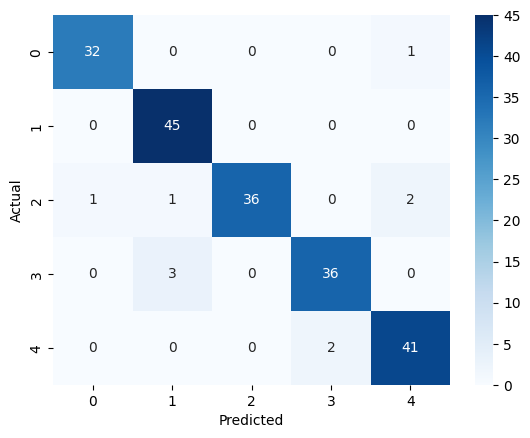

In [ ]:
#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import seaborn as sns
import matplotlib.pyplot as plt
model=LogisticRegression()
model.fit(x_train,y_train)
yp=model.predict(x_test)
lr_acc=accuracy_score(y_test,yp)
print("Accuracy before SMOTE:",lr_acc)
print(classification_report(y_test,yp))
cm=confusion_matrix(y_test,yp)
sns.heatmap(cm,annot=True,fmt='g',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
#Balancing Data
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=42)
x_sm,y_sm=sm.fit_resample(x,y)
x_train_sm,x_test_sm,y_train_sm,y_test_sm=train_test_split(x_sm,y_sm,test_size=0.2,random_state=42)


Accuracies after SMOTE:  0.9707317073170731
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       0.93      1.00      0.97        42
           2       0.98      0.96      0.97        46
           3       0.97      0.95      0.96        40
           4       1.00      0.95      0.97        41

    accuracy                           0.97       205
   macro avg       0.97      0.97      0.97       205
weighted avg       0.97      0.97      0.97       205



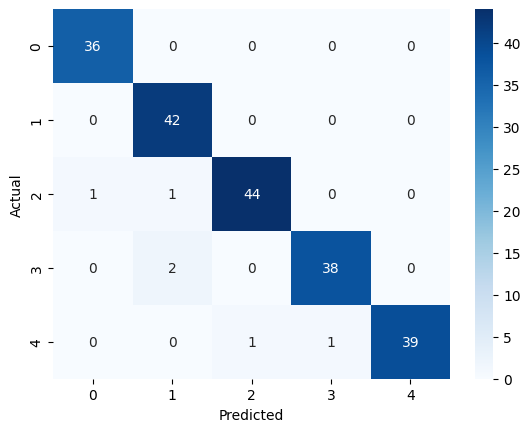

In [ ]:
#AFTER SMOTE LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
model=LogisticRegression(max_iter=1000)
model.fit(x_train_sm,y_train_sm)
yp=model.predict(x_test_sm)
lr_acc_sm=accuracy_score(y_test_sm,yp)
print("Accuracies after SMOTE: ",lr_acc_sm)
print(classification_report(y_test_sm,yp))
cm=confusion_matrix(y_test_sm,yp)
sns.heatmap(cm,annot=True,fmt='g',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


 SVM with linear kernel
Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        33
           1       0.92      1.00      0.96        45
           2       1.00      0.90      0.95        40
           3       0.95      0.92      0.94        39
           4       0.93      0.95      0.94        43

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



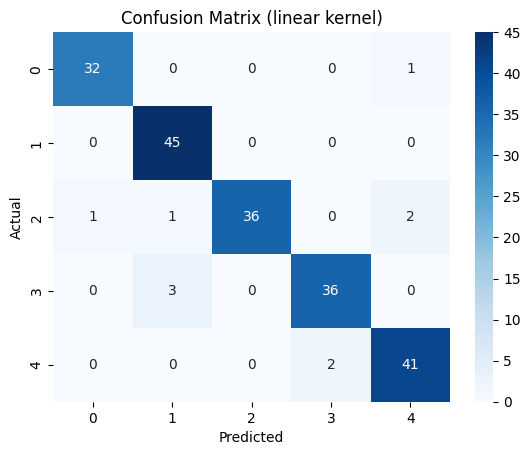


 SVM with poly kernel
Accuracy: 0.935
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        33
           1       0.93      0.93      0.93        45
           2       1.00      0.90      0.95        40
           3       0.95      0.92      0.94        39
           4       0.89      0.95      0.92        43

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



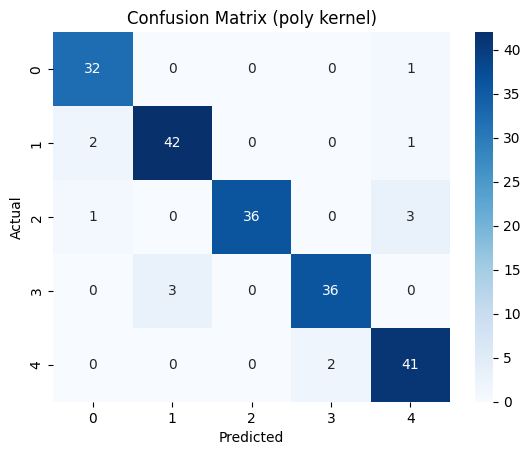


 SVM with rbf kernel
Accuracy: 0.945
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        33
           1       0.92      1.00      0.96        45
           2       1.00      0.88      0.93        40
           3       0.95      0.92      0.94        39
           4       0.91      0.95      0.93        43

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.95       200
weighted avg       0.95      0.94      0.94       200



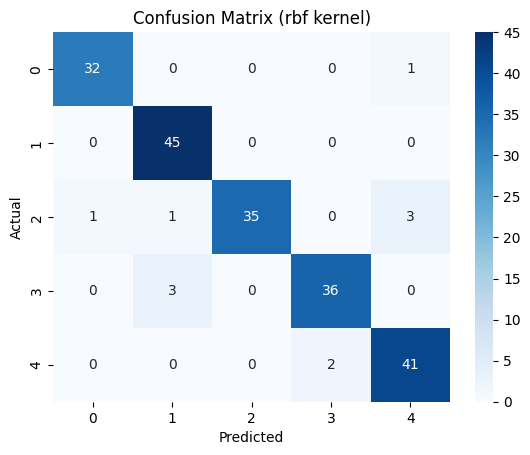


Accuracies List: [0.95, 0.935, 0.945]


In [ ]:
#SVM with linear,poly,RBF kernals
#before smote
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
kernels=['linear', 'poly', 'rbf']
svm_acc=[]
for i in kernels:
    print(f"\n SVM with {i} kernel")
    model=SVC(kernel=i)
    model.fit(x_train, y_train)
    y_pred=model.predict(x_test)
    acc=accuracy_score(y_test, y_pred)
    svm_acc.append(acc)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    cm=confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='g',cmap='Blues')
    plt.title(f"Confusion Matrix ({i} kernel)")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
print("\nAccuracies List:", svm_acc)


 SVM with linear kernel
Accuracy: 0.9707317073170731
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       0.93      1.00      0.97        42
           2       0.98      0.96      0.97        46
           3       0.97      0.95      0.96        40
           4       1.00      0.95      0.97        41

    accuracy                           0.97       205
   macro avg       0.97      0.97      0.97       205
weighted avg       0.97      0.97      0.97       205



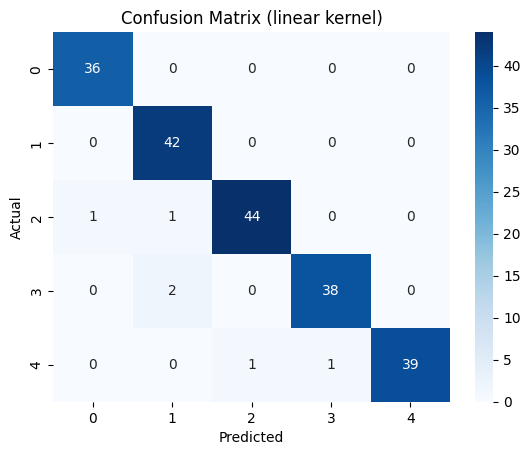


 SVM with poly kernel
Accuracy: 0.9560975609756097
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        36
           1       0.93      0.95      0.94        42
           2       0.98      0.93      0.96        46
           3       0.97      0.95      0.96        40
           4       0.97      0.95      0.96        41

    accuracy                           0.96       205
   macro avg       0.96      0.96      0.96       205
weighted avg       0.96      0.96      0.96       205



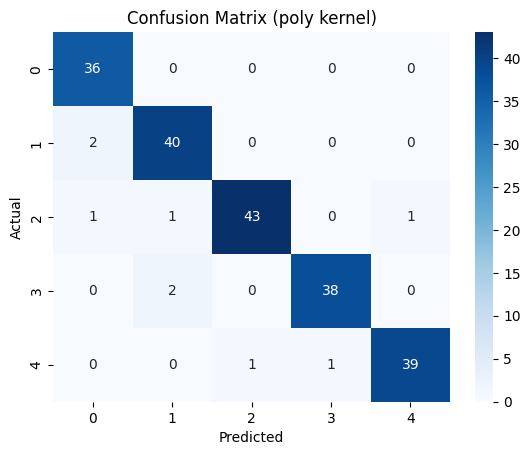


 SVM with rbf kernel
Accuracy: 0.9707317073170731
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       0.93      1.00      0.97        42
           2       0.98      0.96      0.97        46
           3       0.97      0.95      0.96        40
           4       1.00      0.95      0.97        41

    accuracy                           0.97       205
   macro avg       0.97      0.97      0.97       205
weighted avg       0.97      0.97      0.97       205



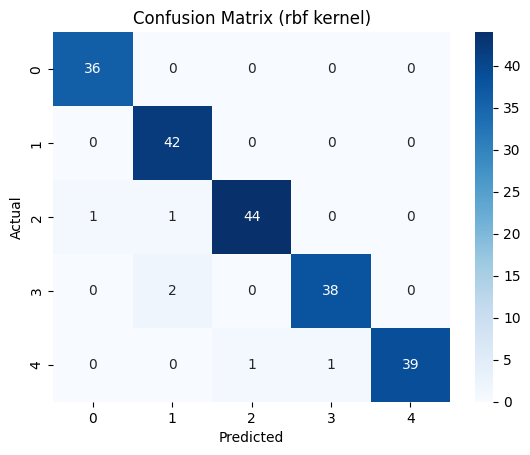


Accuracies List: [0.9707317073170731, 0.9560975609756097, 0.9707317073170731]


In [ ]:
#SVM with linear,poly,RBF kernals
#after smote
svm_acc_sm=[]
for i in kernels:
    print(f"\n SVM with {i} kernel")
    model=SVC(kernel=i)
    model.fit(x_train_sm, y_train_sm)
    y_pred=model.predict(x_test_sm)
    acc_sm=accuracy_score(y_test_sm, y_pred)
    svm_acc_sm.append(acc_sm)
    print("Accuracy:", acc_sm)
    print(classification_report(y_test_sm, y_pred))
    cm=confusion_matrix(y_test_sm, y_pred)
    sns.heatmap(cm, annot=True, fmt='g',cmap='Blues')
    plt.title(f"Confusion Matrix ({i} kernel)")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
print("\nAccuracies List:", svm_acc_sm)

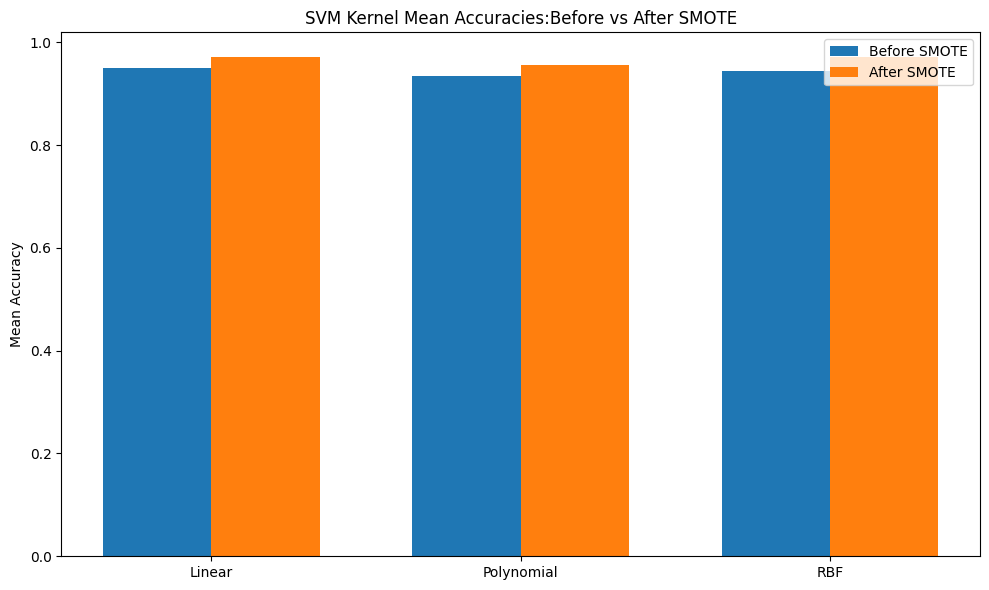

In [ ]:
#COMPARING BEFORE AND AFTER SMOTE RESULTS USING BAR GRAPH
import numpy as np
kernels=['Linear', 'Polynomial', 'RBF']
accuracies_before_smote=[svm_acc[0],svm_acc[1],svm_acc[2]]
accuracies_after_smote=[svm_acc_sm[0],svm_acc_sm[1],svm_acc_sm[2]]
width=0.35
x=np.arange(len(kernels))
fig,ax=plt.subplots(figsize=(10,6))
rects1=ax.bar(x-width/2,accuracies_before_smote,width, label='Before SMOTE')
rects2=ax.bar(x+width/2,accuracies_after_smote, width,label='After SMOTE')
ax.set_ylabel('Mean Accuracy')
ax.set_title('SVM Kernel Mean Accuracies:Before vs After SMOTE')
ax.set_xticks(x)
ax.set_xticklabels(kernels)
ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
#K FOLD FOR LINEAR KERNEL AFTER SMOTE
from sklearn.model_selection import KFold
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
kfold=KFold(n_splits=5,shuffle=True,random_state=42)
accuraciesl=[]
mean_accuracies=[]
for train_index,test_index in kfold.split(x_sm, y_sm):
  x_train,x_test=x_sm.iloc[train_index],x_sm.iloc[test_index]
  y_train,y_test=y_sm.iloc[train_index],y_sm.iloc[test_index]
  model=SVC(kernel="linear")
  model.fit(x_train,y_train)
  y_pred1=model.predict(x_test)
  accuracy=accuracy_score(y_test,y_pred1)
  accuraciesl.append(accuracy)
print("Accuracies:",accuraciesl)
mean_accl=np.mean(accuraciesl)
mean_accuracies.append(mean_accl)
print(f"Mean Accuracy : {mean_accl}")
sum=0
for i in accuraciesl:
  sum+=(i-mean_accl)**2
standard_error=np.sqrt(sum/len(accuraciesl))
print(f"Standard Error : {standard_error}")

Accuracies: [0.9707317073170731, 0.9512195121951219, 0.9512195121951219, 0.9463414634146341, 0.9463414634146341]
Mean Accuracy : 0.953170731707317
Standard Error : 0.009047432678532401


In [ ]:
#K FOLD FOR POLY KERNEL AFTER SMOTE
kfold=KFold(n_splits=5,shuffle=True,random_state=42)
accuracies2l=[]
for train_index,test_index in kfold.split(x_sm, y_sm):
  x_train,x_test=x_sm.iloc[train_index],x_sm.iloc[test_index]
  y_train,y_test=y_sm.iloc[train_index],y_sm.iloc[test_index]
  model=SVC(kernel="poly")
  model.fit(x_train,y_train)
  y_pred2=model.predict(x_test)
  accuracy=accuracy_score(y_test,y_pred2)
  accuracies2l.append(accuracy)
print("Accuracies:",accuracies2l)
a=np.mean(accuracies2l)
mean_accuracies.append(a)
print(f"Mean Accuracy : {a}")
sum=0
for i in accuracies2l:
  sum+=(i-a)**2
standard_error=np.sqrt(sum/len(accuracies2l))
print(f"Standard Error : {standard_error}")

Accuracies: [0.9560975609756097, 0.9560975609756097, 0.9512195121951219, 0.9365853658536586, 0.9414634146341463]
Mean Accuracy : 0.9482926829268292
Standard Error : 0.007925891126474082


In [ ]:
'''K FOLD FOR RBF KERNEL AFTER SMOTE'''
kfold=KFold(n_splits=5,shuffle=True,random_state=42)
accuracies3l=[]
for train_index,test_index in kfold.split(x_sm, y_sm):
  x_train,x_test=x_sm.iloc[train_index],x_sm.iloc[test_index]
  y_train,y_test=y_sm.iloc[train_index],y_sm.iloc[test_index]
  model=SVC(kernel="rbf")
  model.fit(x_train,y_train)
  y_pred3=model.predict(x_test)
  accuracy=accuracy_score(y_test,y_pred3)
  accuracies3l.append(accuracy)
print("Accuracies:",accuracies3l)
mean_acc=np.mean(accuracies3l)
mean_accuracies.append(mean_acc)
print(f"Mean Accuracy : {mean_acc}")
sum=0
for i in accuracies3l:
  sum+=(i-mean_acc)**2
standard_error=np.sqrt(sum/len(accuracies3l))
print(f"Standard Error : {standard_error}")

Accuracies: [0.9707317073170731, 0.9560975609756097, 0.9512195121951219, 0.9463414634146341, 0.9512195121951219]
Mean Accuracy : 0.9551219512195122
Standard Error : 0.008392512455651351


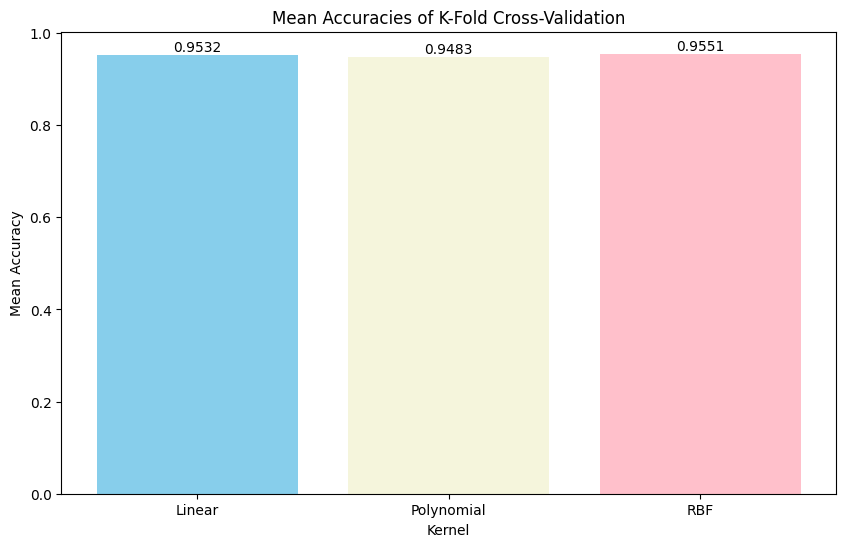

In [ ]:
#Comparing mean accuracies of kfold for linear,poly,rbf
import numpy as np
kernels=['Linear', 'Polynomial', 'RBF']
meanAccuracies=[mean_accuracies[0], mean_accuracies[1],mean_accuracies[2]]
colors = ['skyblue', 'beige', 'pink']
plt.figure(figsize=(10, 6))
bars = plt.bar(kernels, meanAccuracies, color=colors)
plt.xlabel('Kernel')
plt.ylabel('Mean Accuracy')
plt.title('Mean Accuracies of K-Fold Cross-Validation')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, round(yval, 4), ha='center', va='bottom') # +0.001 to slightly offset text from bar
plt.show()

In [ ]:
'''BOOTSTRAPING'''
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
for i in range(0,5):
  #x_train,x_test,y_train,y_test=train_test_split(x_u,y_u,test_size=0.2,random_state=42)
  sc=SVC( max_iter=300)
  m=sc.fit(x_train_sm,y_train_sm)
  yp=m.predict(x_test_sm)
  ACC=accuracy_score(y_test_sm,yp)
  print(f"Accuray for iteration {i} : {ACC}")

Accuray for iteration 0 : 0.9707317073170731
Accuray for iteration 1 : 0.9707317073170731
Accuray for iteration 2 : 0.9707317073170731
Accuray for iteration 3 : 0.9707317073170731
Accuray for iteration 4 : 0.9707317073170731


Accuracies for different k values:  [0.9365853658536586, 0.9317073170731708, 0.9707317073170731, 0.9707317073170731, 0.9658536585365853, 0.9658536585365853, 0.9658536585365853, 0.9609756097560975, 0.9609756097560975, 0.9609756097560975, 0.9658536585365853, 0.9609756097560975, 0.9609756097560975, 0.9560975609756097, 0.9512195121951219, 0.9512195121951219, 0.9463414634146341, 0.9463414634146341, 0.9365853658536586, 0.9365853658536586, 0.9365853658536586, 0.9365853658536586, 0.9365853658536586, 0.9365853658536586, 0.9365853658536586, 0.926829268292683, 0.926829268292683, 0.926829268292683, 0.926829268292683, 0.9219512195121952, 0.9219512195121952, 0.9170731707317074, 0.9121951219512195, 0.9073170731707317, 0.9170731707317074, 0.9073170731707317, 0.9121951219512195]
Max Accuracy:  0.9707317073170731
best K-value: 3
Accuracy with best K: 0.9707317073170731


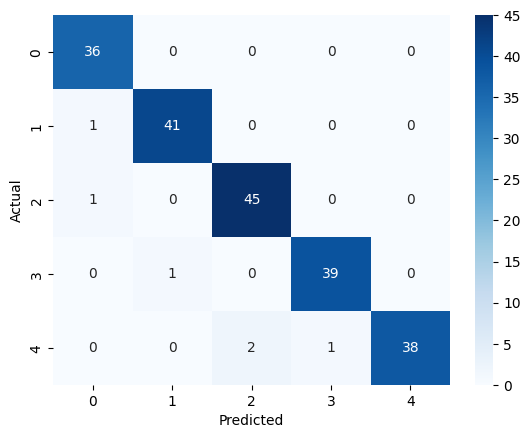

Classification Report: 
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        36
           1       0.98      0.98      0.98        42
           2       0.96      0.98      0.97        46
           3       0.97      0.97      0.97        40
           4       1.00      0.93      0.96        41

    accuracy                           0.97       205
   macro avg       0.97      0.97      0.97       205
weighted avg       0.97      0.97      0.97       205



In [ ]:
#KNN Classification
from numpy._core.fromnumeric import argmax
from sklearn.neighbors import KNeighborsClassifier
k_values=range(1, int(np.sqrt(len(x_train_sm))) + 10)
accuracy=[]
for i in k_values:
  knn=KNeighborsClassifier(n_neighbors=i)
  knn.fit(x_train_sm,y_train_sm)
  y_pred=knn.predict(x_test_sm)
  accuracy.append(accuracy_score(y_test_sm,y_pred))
print('Accuracies for different k values: ',accuracy)
print('Max Accuracy: ',max(accuracy))
best_k=k_values[np.argmax(accuracy)]
print("best K-value:",best_k)
knn=KNeighborsClassifier(n_neighbors=best_k)
knn.fit(x_train_sm,y_train_sm)
y_p=knn.predict(x_test_sm)
knn_acc=accuracy_score(y_test_sm,y_p)
print("Accuracy with best K:",knn_acc)
cm=confusion_matrix(y_test_sm,y_p)
sns.heatmap(cm,annot=True,fmt='g',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("Classification Report: \n",classification_report(y_test_sm,y_p))

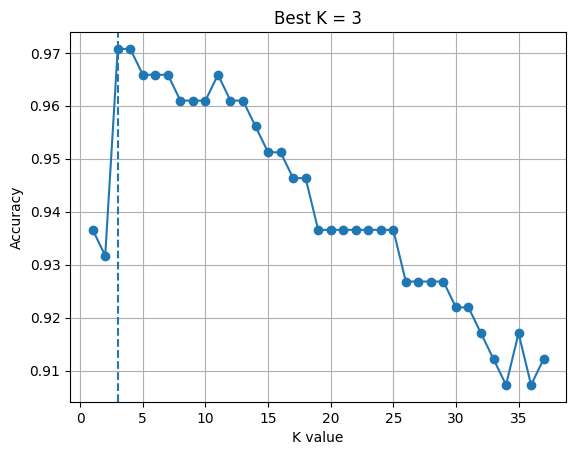

In [ ]:
plt.figure()
plt.plot(k_values, accuracy, marker='o')
plt.axvline(x=best_k, linestyle='--')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.title(f'Best K = {best_k}')
plt.grid()
plt.show()

In [ ]:
#random search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
param_dist={'C':[0.1,1,10,0.015],'gamma':[1,0.1,0.01,0.5],'kernel':['rbf','linear','poly']}
random=RandomizedSearchCV(SVC(),param_distributions=param_dist,n_iter=5,cv=5)
random.fit(x_train_sm,y_train_sm)
random_pred=random.predict(x_test_sm)
random_acc=accuracy_score(y_test_sm,random_pred)
print("Random accuracy: ",random_acc)

Random accuracy:  0.9658536585365853


In [ ]:
#grid search
from sklearn.model_selection import GridSearchCV
param_grid={'C':[0.1,1,10,0.5],'gamma':[1,0.1,0.01,0.25],'kernel':['rbf','linear','poly']}
grid=GridSearchCV(SVC(),param_grid=param_grid,cv=5)
grid.fit(x_train_sm,y_train_sm)
grid_pred=grid.predict(x_test_sm)
grid_acc=accuracy_score(y_test_sm,grid_pred)
print("Grid Accuracy: ",grid_acc)


Grid Accuracy:  0.9658536585365853


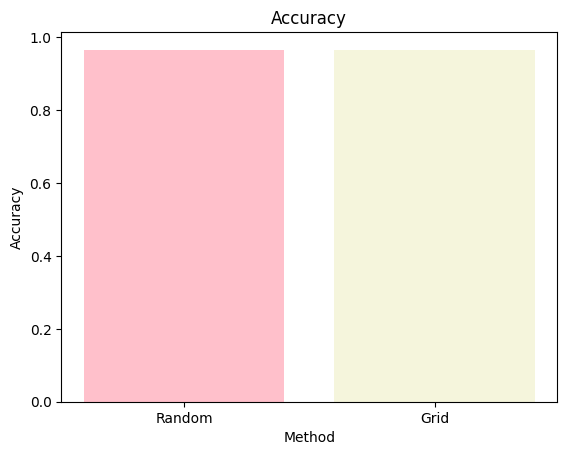

In [ ]:
#plot
import matplotlib.pyplot as plt
import numpy as np
method=['Random','Grid']
accuracy=[random_acc,grid_acc]
plt.bar(method,accuracy,color=['pink','beige'])
plt.xlabel('Method')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.show()

Accuracy: 0.9365853658536586

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        36
           1       0.82      0.98      0.89        42
           2       0.98      0.91      0.94        46
           3       0.97      0.95      0.96        40
           4       1.00      0.90      0.95        41

    accuracy                           0.94       205
   macro avg       0.94      0.94      0.94       205
weighted avg       0.94      0.94      0.94       205



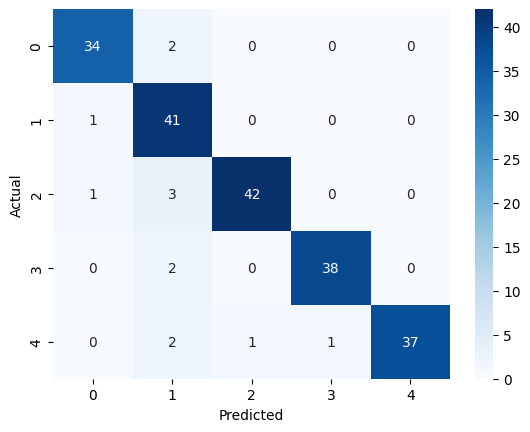

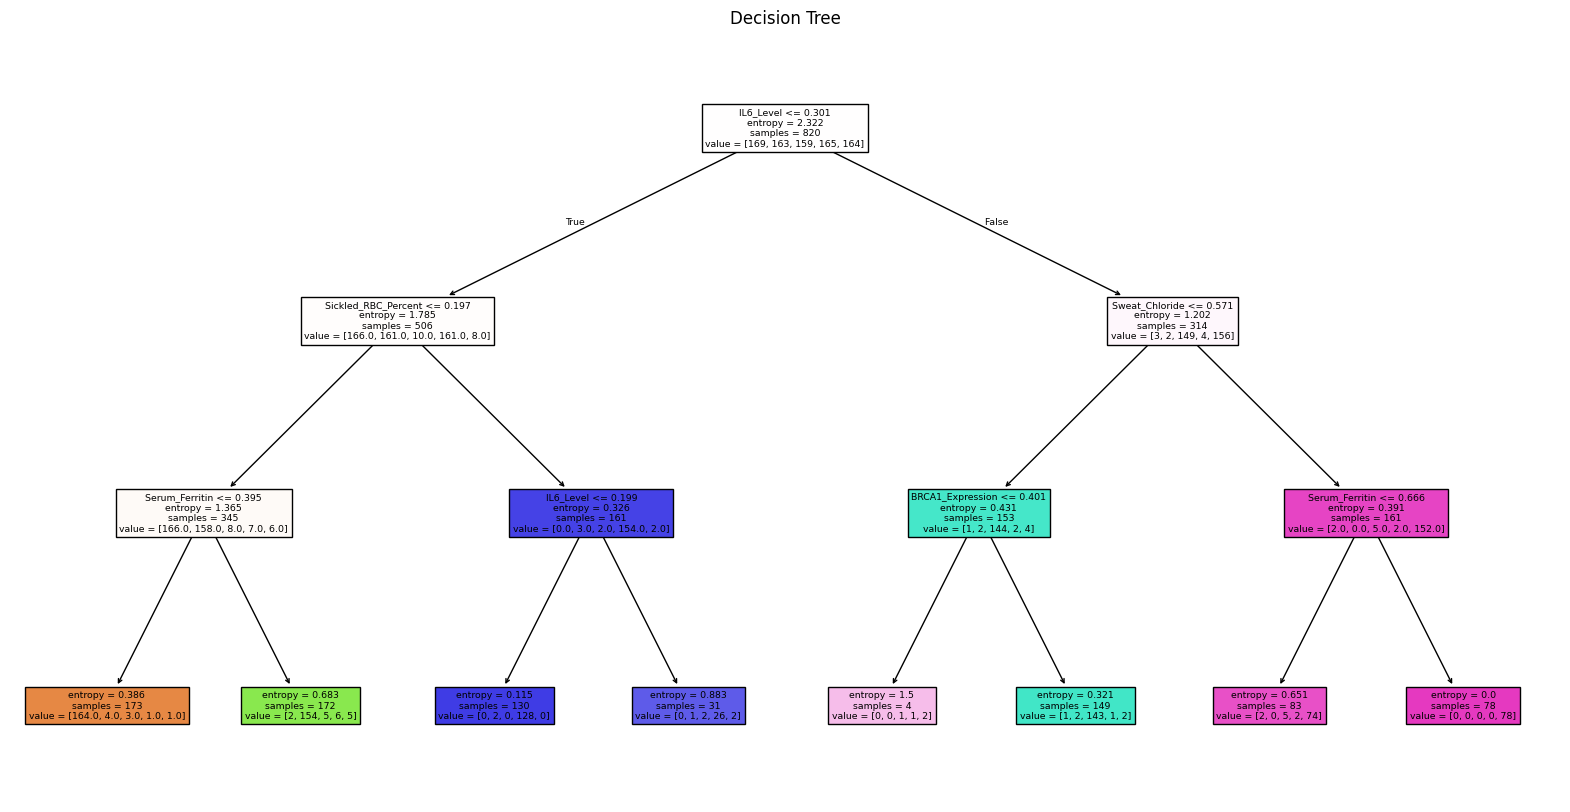

In [ ]:
#DECISION TREE
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
model = DecisionTreeClassifier(criterion='entropy', max_depth=3,random_state=42)
model.fit(x_train_sm, y_train_sm)
y_pred = model.predict(x_test_sm)
DT_accuracy = accuracy_score(y_test_sm, y_pred)
print("Accuracy:", DT_accuracy)
print("\nClassification Report:\n", classification_report(y_test_sm, y_pred))
cm = confusion_matrix(y_test_sm, y_pred)
sns.heatmap(cm, annot=True, fmt='g',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=x_train_sm.columns, filled=True)
plt.title("Decision Tree")
plt.show()

In [ ]:
#Principal Component Analysis(PCA)
from sklearn.decomposition import PCA
pca=PCA(n_components=0.95)
x_train_pca=pca.fit_transform(x_train_sm)
x_test_pca=pca.transform(x_test_sm)
print("Before PCA: ")
print(x_train_sm.shape)
print(x_test_sm.shape)
print("After PCA: ")
print( x_train_pca.shape)
print(x_test_pca.shape)

Before PCA: 
(820, 12)
(205, 12)
After PCA: 
(820, 8)
(205, 8)


Accuracy:  0.9707317073170731

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        36
           1       0.95      0.98      0.96        42
           2       0.98      0.98      0.98        46
           3       0.97      0.95      0.96        40
           4       1.00      0.95      0.97        41

    accuracy                           0.97       205
   macro avg       0.97      0.97      0.97       205
weighted avg       0.97      0.97      0.97       205



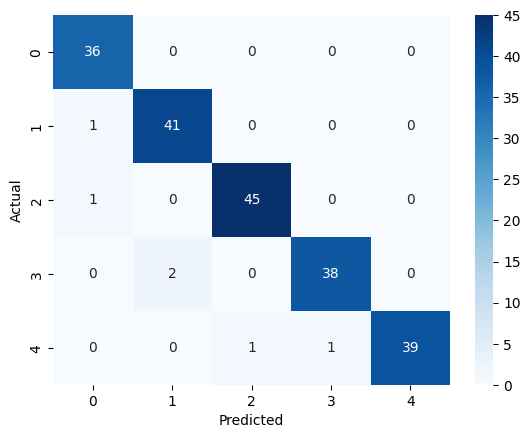

In [ ]:
#random forest
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train_sm,y_train_sm)
y_pred=model.predict(x_test_sm)
RF_accuracy=accuracy_score(y_test_sm,y_pred)
print("Accuracy: ",RF_accuracy)
print("\nClassification Report:\n",classification_report(y_test_sm,y_pred))
cm=confusion_matrix(y_test_sm,y_pred)
sns.heatmap(cm,annot=True,fmt='g',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()




Accuracy:  0.9707317073170731

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.95      1.00      0.98        42
           2       0.98      0.98      0.98        46
           3       0.95      0.95      0.95        40
           4       1.00      0.95      0.97        41

    accuracy                           0.97       205
   macro avg       0.97      0.97      0.97       205
weighted avg       0.97      0.97      0.97       205



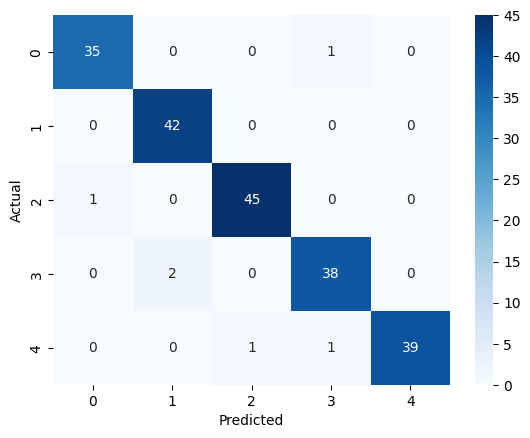

In [ ]:
#Random forest after PCA
model=RandomForestClassifier(n_estimators=100,random_state=4)
model.fit(x_train_pca,y_train_sm)
y_pred=model.predict(x_test_pca)
RF_accuracy_pca=accuracy_score(y_test_sm,y_pred)
print("Accuracy: ",RF_accuracy_pca)
print("\nClassification Report:\n",classification_report(y_test_sm,y_pred))
cm=confusion_matrix(y_test_sm,y_pred)
sns.heatmap(cm,annot=True,fmt='g',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

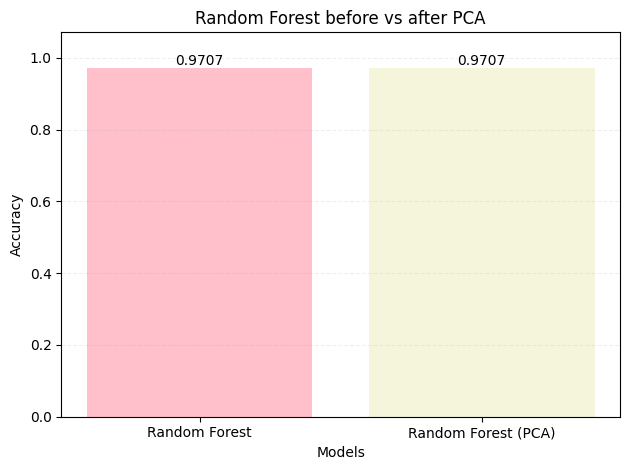

In [ ]:
#plot Random Forest before vs after PCA
import matplotlib.pyplot as plt
import numpy as np
models = ['Random Forest', 'Random Forest (PCA)']
accuracies = [RF_accuracy, RF_accuracy_pca]
plt.figure()
colors = ['pink', 'beige']
bars = plt.bar(models, accuracies, color=colors)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Random Forest before vs after PCA')
plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.ylim(0, max(accuracies) + 0.1)
plt.tight_layout()
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.4f}',
             ha='center',
             va='bottom')
plt.show()

Accuracy: 0.9609756097560975

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        36
           1       0.91      0.98      0.94        42
           2       0.98      0.96      0.97        46
           3       0.97      0.95      0.96        40
           4       1.00      0.95      0.97        41

    accuracy                           0.96       205
   macro avg       0.96      0.96      0.96       205
weighted avg       0.96      0.96      0.96       205



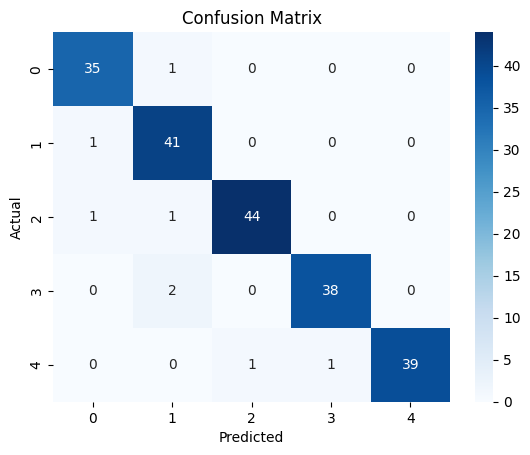

In [ ]:
#Aadaboost
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=100,learning_rate=0.5)
model.fit(x_train_sm, y_train_sm)
y_pred = model.predict(x_test_sm)
AB_accuracy = accuracy_score(y_test_sm, y_pred)
print("Accuracy:", AB_accuracy)
print("\nClassification Report:\n", classification_report(y_test_sm, y_pred))
cm = confusion_matrix(y_test_sm, y_pred)
sns.heatmap(cm, annot=True, fmt='g',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix")
plt.show()

Accuracy: 0.9560975609756097

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95        36
           1       0.95      0.93      0.94        42
           2       0.98      0.98      0.98        46
           3       0.97      0.95      0.96        40
           4       0.95      0.95      0.95        41

    accuracy                           0.96       205
   macro avg       0.96      0.96      0.96       205
weighted avg       0.96      0.96      0.96       205



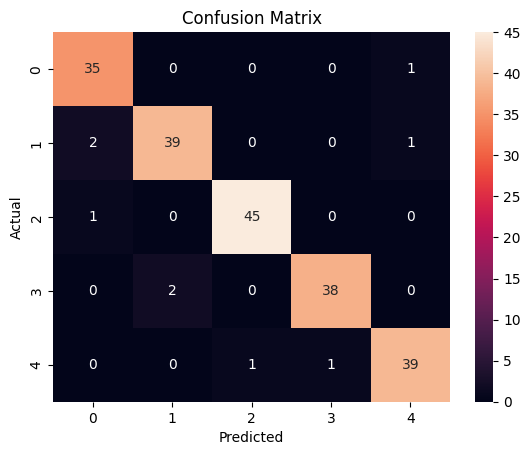

In [ ]:
#Aadaboost after PCA
model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=100,learning_rate=0.5)
model.fit(x_train_pca, y_train_sm)
y_pred = model.predict(x_test_pca)
AB_accuracy_pca=accuracy_score(y_test_sm, y_pred)
print("Accuracy:", AB_accuracy_pca)
print("\nClassification Report:\n", classification_report(y_test_sm, y_pred))
cm=confusion_matrix(y_test_sm,y_pred)
sns.heatmap(cm,annot=True,fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix")
plt.show()

Accuracy:  0.9609756097560975

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.91      0.98      0.94        42
           2       0.98      0.96      0.97        46
           3       1.00      0.95      0.97        40
           4       0.95      0.95      0.95        41

    accuracy                           0.96       205
   macro avg       0.96      0.96      0.96       205
weighted avg       0.96      0.96      0.96       205



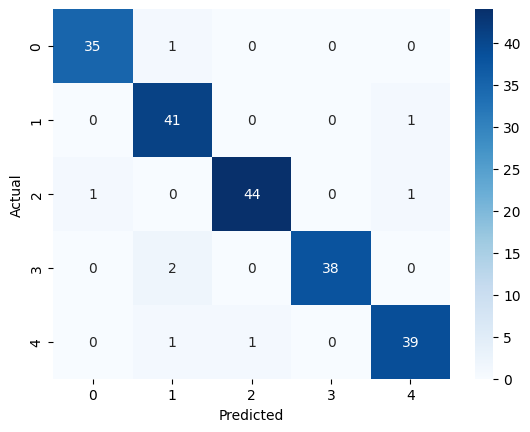

In [ ]:
#GBoost
from sklearn.ensemble import GradientBoostingClassifier
model=GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
model.fit(x_train_sm,y_train_sm)
y_pred=model.predict(x_test_sm)
GB_accuracy=accuracy_score(y_test_sm,y_pred)
print("Accuracy: ",GB_accuracy)
print("\nClassification Report:\n",classification_report(y_test_sm,y_pred))
cm=confusion_matrix(y_test_sm,y_pred)
sns.heatmap(cm,annot=True,fmt='g',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



Accuracy:  0.9512195121951219

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        36
           1       0.91      0.98      0.94        42
           2       0.98      0.96      0.97        46
           3       0.97      0.90      0.94        40
           4       0.95      0.95      0.95        41

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205



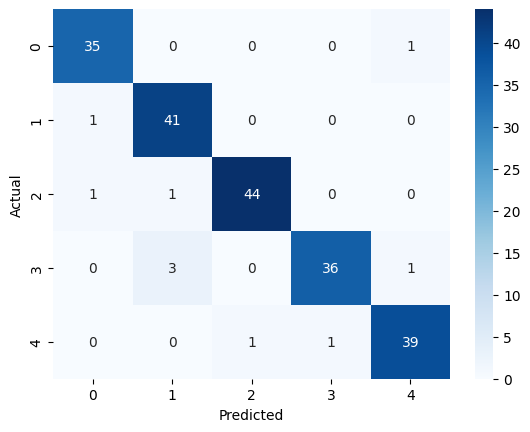

In [ ]:
#GBoost after pca
model=GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
model.fit(x_train_pca,y_train_sm)
y_pred=model.predict(x_test_pca)
GB_accuracy_pca=accuracy_score(y_test_sm,y_pred)
print("Accuracy: ",GB_accuracy_pca)
print("\nClassification Report:\n",classification_report(y_test_sm,y_pred))
cm=confusion_matrix(y_test_sm,y_pred)
sns.heatmap(cm,annot=True,fmt='g',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:21:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy:  0.9707317073170731

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.93      1.00      0.97        42
           2       0.98      0.98      0.98        46
           3       0.97      0.95      0.96        40
           4       1.00      0.95      0.97        41

    accuracy                           0.97       205
   macro avg       0.97      0.97      0.97       205
weighted avg       0.97      0.97      0.97       205



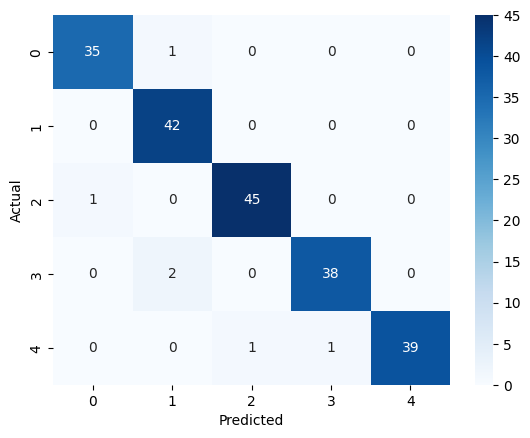

In [ ]:
#XGBoost
from xgboost import XGBClassifier
model=XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
model.fit(x_train_sm,y_train_sm)
y_pred=model.predict(x_test_sm)
XGB_accuracy=accuracy_score(y_test_sm,y_pred)
print("Accuracy: ",XGB_accuracy)
print("\nClassification Report:\n",classification_report(y_test_sm,y_pred))
cm=confusion_matrix(y_test_sm,y_pred)
sns.heatmap(cm,annot=True,fmt='g',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



XGBoost After PCA



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:21:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy:  0.975609756097561

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       0.95      1.00      0.98        42
           2       0.98      0.98      0.98        46
           3       0.97      0.95      0.96        40
           4       1.00      0.95      0.97        41

    accuracy                           0.98       205
   macro avg       0.98      0.98      0.98       205
weighted avg       0.98      0.98      0.98       205


 confusion matrix



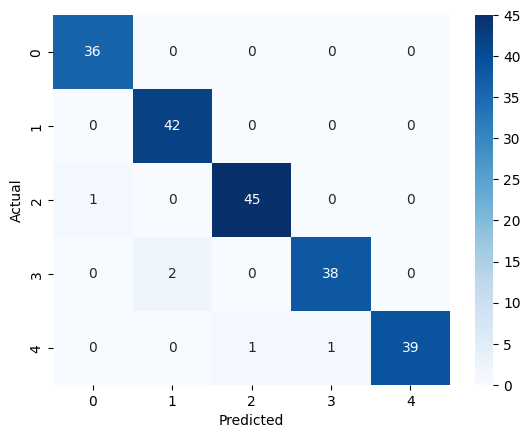

In [ ]:
#XGBoost after pca
print("\nXGBoost After PCA\n")
model=XGBClassifier(n_estimators=100,random_state=42,use_label_encoder=False,eval_metric='mlogloss')
model.fit(x_train_pca,y_train_sm)
y_pred=model.predict(x_test_pca)
XGB_accuracy_pca=accuracy_score(y_test_sm,y_pred)
print("Accuracy: ",XGB_accuracy_pca)
print("\nClassification Report:\n",classification_report(y_test_sm,y_pred))
print("\n confusion matrix\n")
cm=confusion_matrix(y_test_sm,y_pred)
sns.heatmap(cm,annot=True,fmt='g',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


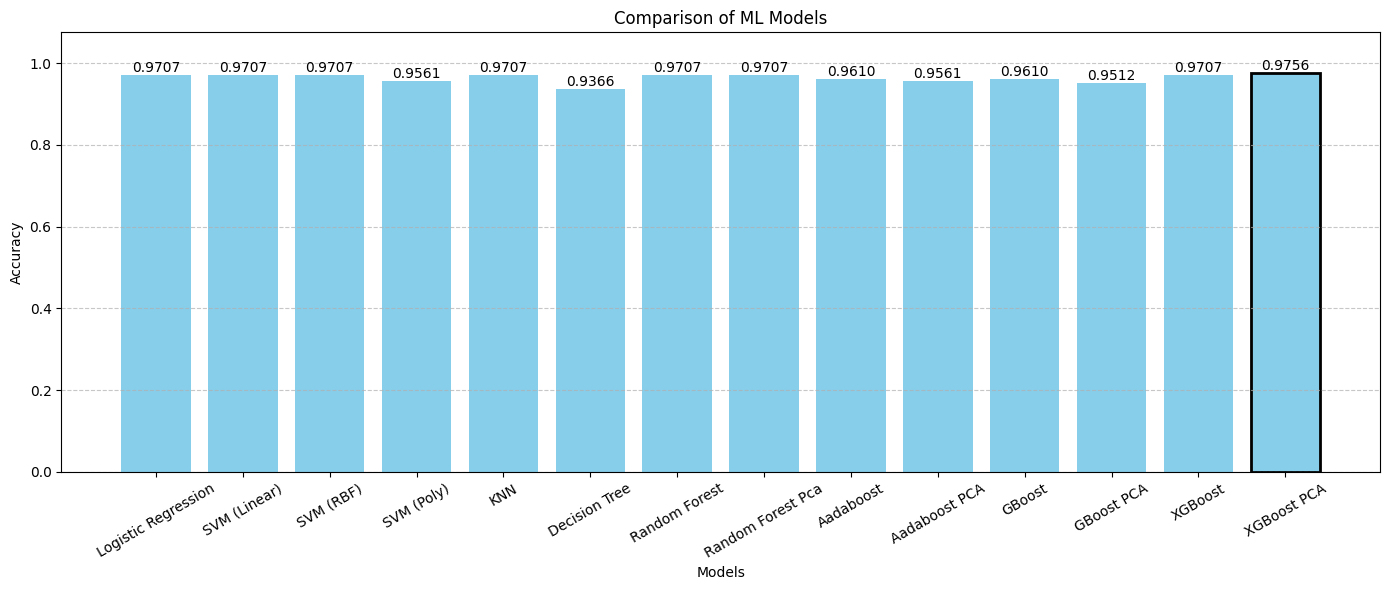

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
models = ['Logistic Regression','SVM (Linear)', 'SVM (RBF)', 'SVM (Poly)', 'KNN', 'Decision Tree','Random Forest','Random Forest Pca','Aadaboost','Aadaboost PCA','GBoost','GBoost PCA','XGBoost','XGBoost PCA']
accuracies = [lr_acc_sm,svm_acc_sm[0], svm_acc_sm[2], svm_acc_sm[1], knn_acc, DT_accuracy,RF_accuracy,RF_accuracy_pca,AB_accuracy,AB_accuracy_pca,GB_accuracy,GB_accuracy_pca,XGB_accuracy,XGB_accuracy_pca]
plt.figure(figsize=(14,6))
bars = plt.bar(models, accuracies,color='skyblue')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Comparison of ML Models')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.4f}',
             ha='center',
             va='bottom')
best_index = np.argmax(accuracies)
bars[best_index].set_edgecolor('black')
bars[best_index].set_linewidth(2)
plt.xticks(rotation=30)
plt.ylim(0, max(accuracies) + 0.1)
plt.tight_layout()
plt.show()